# Master Pipeline for data loading, transformation, machine learning, and evaluation

In [1]:
import duckdb
import pandas as pd
import logging
import os
from pathlib import Path

# Setup logging
logging.basicConfig(
    filename='../logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

In [ ]:
DB_PATH = '../data/conflict_prediction.duckdb'
os.makedirs('../data', exist_ok=True)
os.makedirs('../logs', exist_ok=True)

# setting up logger and connection
con = duckdb.connect(DB_PATH)
logger.info("Connected to DuckDB database")
print("Connected to DuckDB database")

DATA_DIR = '../data/raw' 

# files
FILES = {
    'acled': f'{DATA_DIR}Middle-East_aggregated_data_up_to-2026-03-07.csv',
    'gdelt': f'{DATA_DIR}gdelt_middle_east.csv',
    'sipri': f'{DATA_DIR}SIPRI_current_USD.csv',
    'sipri_per_capita': f'{DATA_DIR}SIPRI_per_capita.csv',
    'fsi_2019': f'{DATA_DIR}fsi-2019.csv',
    'fsi_2020': f'{DATA_DIR}fsi-2020.csv',
    'fsi_2021': f'{DATA_DIR}fsi-2021.csv',
    'fsi_2022': f'{DATA_DIR}fsi-2022.csv',
    'fsi_2023': f'{DATA_DIR}fsi-2023.csv',
    'acled_index': f'{DATA_DIR}ACLED_ci.csv',
    'world_bank': f'{DATA_DIR}World_bank_hist.csv',
}

# Verify files exist
for name, path in FILES.items():
    exists = os.path.exists(path)
    status = "FOUND" if exists else "MISSING"
    print(f"  {status}: {name} -> {path}")
    if not exists:
        logger.warning(f"File not found: {path}")

Connected to DuckDB database
  FOUND: acled -> ../data/Middle-East_aggregated_data_up_to-2026-03-07.csv
  FOUND: gdelt -> ../data/gdelt_middle_east.csv
  FOUND: sipri -> ../data/SIPRI_current_USD.csv
  FOUND: sipri_per_capita -> ../data/SIPRI_per_capita.csv
  FOUND: fsi_2019 -> ../data/fsi-2019.csv
  FOUND: fsi_2020 -> ../data/fsi-2020.csv
  FOUND: fsi_2021 -> ../data/fsi-2021.csv
  FOUND: fsi_2022 -> ../data/fsi-2022.csv
  FOUND: fsi_2023 -> ../data/fsi-2023.csv
  FOUND: acled_index -> ../data/ACLED_ci.csv
  FOUND: world_bank -> ../data/World_bank_hist.csv


In [3]:
# Middle East countries with code mappings
countries_data = {
    'country_code': ['BHR','IRN','IRQ','ISR','JOR','KWT','LBN','OMN','PSE','QAT','SAU','SYR','TUR','ARE','YEM'],
    'country_name': ['Bahrain','Iran','Iraq','Israel','Jordan','Kuwait','Lebanon','Oman','Palestine','Qatar','Saudi Arabia','Syria','Turkey','United Arab Emirates','Yemen'],
    'fips_code': ['BA','IR','IZ','IS','JO','KU','LE','MU','WE','QA','SA','SY','TU','AE','YM'],
    'acled_name': ['Bahrain','Iran','Iraq','Israel','Jordan','Kuwait','Lebanon','Oman','Palestine','Qatar','Saudi Arabia','Syria','Turkey','United Arab Emirates','Yemen'],
    'region': ['Middle East'] * 15,
}

countries_df = pd.DataFrame(countries_data)

# Add World Bank classification if file exists
try:
    wb = pd.read_csv(FILES['world_bank'])
    # Map to our countries
    for idx, row in countries_df.iterrows():
        match = wb[wb['Country'].str.contains(row['country_name'], case=False, na=False)]
        if len(match) > 0:
            countries_df.loc[idx, 'income_group'] = match.iloc[0].get('FY26', 'Unknown')
            countries_df.loc[idx, 'lending_category'] = 'Unknown'
    logger.info("Added World Bank classifications")
except Exception as e:
    logger.warning(f"Could not load World Bank data: {e}")
    countries_df['income_group'] = 'Unknown'
    countries_df['lending_category'] = 'Unknown'

con.execute("DROP TABLE IF EXISTS countries")
con.execute("""
    CREATE TABLE countries AS SELECT * FROM countries_df
""")
print(f"COUNTRIES table created: {con.execute('SELECT COUNT(*) FROM countries').fetchone()[0]} rows")
logger.info("COUNTRIES table created")

COUNTRIES table created: 15 rows


In [4]:
try:
    acled = pd.read_csv(FILES['acled'])
    
    # Rename columns to clean format
    acled.columns = [c.lower().replace(' ', '_') for c in acled.columns]
    
    # Rename week to event_date if needed
    if 'week' in acled.columns:
        acled = acled.rename(columns={'week': 'event_date'})
    
    # Add country_code by mapping from COUNTRIES
    country_map = dict(zip(countries_df['acled_name'], countries_df['country_code']))
    acled['country_code'] = acled['country'].map(country_map)
    
    con.execute("DROP TABLE IF EXISTS acled_events")
    con.execute("""
        CREATE TABLE acled_events AS SELECT * FROM acled
    """)
    
    row_count = con.execute('SELECT COUNT(*) FROM acled_events').fetchone()[0]
    print(f"ACLED_EVENTS table created: {row_count:,} rows")
    logger.info(f"ACLED_EVENTS table created: {row_count} rows")
    
except Exception as e:
    print(f"ERROR loading ACLED: {e}")
    logger.error(f"ACLED loading failed: {e}")

ACLED_EVENTS table created: 144,526 rows


In [5]:
try:
    gdelt = pd.read_csv(FILES['gdelt'], dtype=str, low_memory=False)
    
    # Add country_code by mapping FIPS -> ISO
    fips_map = dict(zip(countries_df['fips_code'], countries_df['country_code']))
    gdelt['country_code'] = gdelt['ActionGeo_CountryCode'].map(fips_map)
    
    # Convert numeric columns
    for col in ['GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 
                'AvgTone', 'ActionGeo_Lat', 'ActionGeo_Long']:
        gdelt[col] = pd.to_numeric(gdelt[col], errors='coerce')

    # Filter only countries we care about
    gdelt_me = gdelt.dropna(subset=['country_code'])
    
    con.execute("DROP TABLE IF EXISTS gdelt_events")
    con.execute("""
        CREATE TABLE gdelt_events AS SELECT * FROM gdelt_me
    """)
    
    row_count = con.execute('SELECT COUNT(*) FROM gdelt_events').fetchone()[0]
    print(f"GDELT_EVENTS table created: {row_count:,} rows")
    logger.info(f"GDELT_EVENTS table created: {row_count} rows")
    
except Exception as e:
    print(f"ERROR loading GDELT: {e}")
    logger.error(f"GDELT loading failed: {e}")

GDELT_EVENTS table created: 2,148,627 rows


In [6]:
try:
    sipri = pd.read_csv(FILES['sipri'])
    
    # SIPRI data is wide format (one column per year) — melt to long format
    id_cols = ['Country', 'Notes']
    year_cols = [c for c in sipri.columns if c not in id_cols]
    
    sipri_long = sipri.melt(
        id_vars=['Country'], 
        value_vars=year_cols,
        var_name='year', 
        value_name='spending_current_usd'
    )
    
    # Clean up
    sipri_long['year'] = pd.to_numeric(sipri_long['year'], errors='coerce')
    sipri_long['spending_current_usd'] = pd.to_numeric(
        sipri_long['spending_current_usd'].replace(['...', 'xxx', '..'], pd.NA), 
        errors='coerce'
    )
    sipri_long = sipri_long.dropna(subset=['year', 'spending_current_usd'])
    sipri_long['year'] = sipri_long['year'].astype(int)
    
    # Filter to Middle East countries and map codes
    me_names = countries_df['country_name'].tolist()
    # SIPRI may use slightly different names, so do fuzzy matching
    name_map = {}
    for sipri_name in sipri_long['Country'].unique():
        for me_name in me_names:
            if me_name.lower() in sipri_name.lower() or sipri_name.lower() in me_name.lower():
                name_map[sipri_name] = me_name
                break
    
    sipri_long['matched_name'] = sipri_long['Country'].map(name_map)
    sipri_me = sipri_long.dropna(subset=['matched_name']).copy()
    
    country_code_map = dict(zip(countries_df['country_name'], countries_df['country_code']))
    sipri_me['country_code'] = sipri_me['matched_name'].map(country_code_map)
    sipri_me = sipri_me[['country_code', 'year', 'spending_current_usd']]
    
    con.execute("DROP TABLE IF EXISTS military_spending")
    con.execute("""
        CREATE TABLE military_spending AS SELECT * FROM sipri_me
    """)
    
    row_count = con.execute('SELECT COUNT(*) FROM military_spending').fetchone()[0]
    print(f"MILITARY_SPENDING table created: {row_count:,} rows")
    logger.info(f"MILITARY_SPENDING table created: {row_count} rows")
    
except Exception as e:
    print(f"ERROR loading SIPRI: {e}")
    logger.error(f"SIPRI loading failed: {e}")

MILITARY_SPENDING table created: 758 rows


In [7]:
try:
    fsi_frames = []
    fsi_keys = [k for k in FILES if k.startswith('fsi_')]
    
    for key in fsi_keys:
        try:
            df = pd.read_csv(FILES[key])
            # Standardize column names
            df.columns = [c.strip() for c in df.columns]
            fsi_frames.append(df)
            print(f"  Loaded {key}: {len(df)} rows, year(s): {df['Year'].unique()}")
        except Exception as e:
            print(f"  Skipped {key}: {e}")
    
    if fsi_frames:
        fsi = pd.concat(fsi_frames, ignore_index=True)
        
        # Standardize column names
        fsi = fsi.rename(columns={
            'S1: Demographic Pressures': 'demographic_pressures',
            'S2: Refugees and IDPs': 'refugees_idps',
            'C3: Group Grievance': 'group_grievance',
            'E3: Human Flight and Brain Drain': 'human_flight',
            'E2: Economic Inequality': 'economic_inequality',
            'E1: Economy': 'economy',
            'P1: State Legitimacy': 'state_legitimacy',
            'P2: Public Services': 'public_services',
            'P3: Human Rights': 'human_rights',
            'C1: Security Apparatus': 'security_apparatus',
            'C2: Factionalized Elites': 'factionalized_elites',
            'X1: External Intervention': 'external_intervention',
            'Total': 'total_score',
            'Country': 'country_name',
            'Year': 'year'
        })
        
        # Map country codes
        code_map = dict(zip(countries_df['country_name'], countries_df['country_code']))
        fsi['country_code'] = fsi['country_name'].map(code_map)
        fsi_me = fsi.dropna(subset=['country_code'])
        
        # Select final columns
        fsi_cols = ['country_code', 'year', 'total_score', 'demographic_pressures',
                    'refugees_idps', 'group_grievance', 'human_flight', 
                    'economic_inequality', 'economy', 'state_legitimacy',
                    'public_services', 'human_rights', 'security_apparatus',
                    'factionalized_elites', 'external_intervention']
        fsi_me = fsi_me[[c for c in fsi_cols if c in fsi_me.columns]]
        
        con.execute("DROP TABLE IF EXISTS fragile_states_index")
        con.execute("""
            CREATE TABLE fragile_states_index AS SELECT * FROM fsi_me
        """)
        
        row_count = con.execute('SELECT COUNT(*) FROM fragile_states_index').fetchone()[0]
        print(f"FRAGILE_STATES_INDEX table created: {row_count:,} rows")
        logger.info(f"FRAGILE_STATES_INDEX table created: {row_count} rows")
        
except Exception as e:
    print(f"ERROR loading FSI: {e}")
    logger.error(f"FSI loading failed: {e}")

  Loaded fsi_2019: 2099 rows, year(s): [2019.   nan]
  Loaded fsi_2020: 2099 rows, year(s): [2020.   nan]
  Loaded fsi_2021: 179 rows, year(s): [2021]
  Loaded fsi_2022: 2991 rows, year(s): [2022.   nan]
  Loaded fsi_2023: 179 rows, year(s): [2023]
FRAGILE_STATES_INDEX table created: 71 rows


In [8]:
try:
    aci = pd.read_csv(FILES['acled_index'])
    
    print(f"  Raw columns: {list(aci.columns)}")
    print(f"  Shape: {aci.shape}")
    print(f"  First few rows:")
    print(aci.head(3))
    
    # Map country codes — adjust column names based on what you see above
    # You may need to update these mappings based on the actual column names
    code_map = dict(zip(countries_df['country_name'], countries_df['country_code']))
    
    # Try common column name patterns
    country_col = None
    for candidate in ['Country', 'country', 'Country/Territory', 'Name']:
        if candidate in aci.columns:
            country_col = candidate
            break
    
    if country_col:
        aci['country_code'] = aci[country_col].map(code_map)
        aci_me = aci.dropna(subset=['country_code'])
        
        con.execute("DROP TABLE IF EXISTS acled_conflict_index")
        con.execute("""
            CREATE TABLE acled_conflict_index AS SELECT * FROM aci_me
        """)
        
        row_count = con.execute('SELECT COUNT(*) FROM acled_conflict_index').fetchone()[0]
        print(f"ACLED_CONFLICT_INDEX table created: {row_count:,} rows")
        logger.info(f"ACLED_CONFLICT_INDEX table created: {row_count} rows")
    else:
        print(f"  Could not find country column. Available: {list(aci.columns)}")
        print("  Update the column name mapping above.")
    
except Exception as e:
    print(f"ERROR loading ACLED Conflict Index: {e}")
    logger.error(f"ACLED Conflict Index loading failed: {e}")

  Raw columns: ['Country', 'Index Level', 'Index Ranking', 'Deadliness Ranking', 'Diffusion Ranking', 'Danger Ranking', 'Fragmentation Ranking', 'Deadliness Value', 'Diffusion Value', 'Danger Value', 'Fragmentation Value']
  Shape: (244, 11)
  First few rows:
     Country Index Level  Index Ranking  Deadliness Ranking  \
0  Palestine     Extreme              1                   3   
1    Myanmar     Extreme              2                   4   
2      Syria     Extreme              3                   7   

   Diffusion Ranking  Danger Ranking  Fragmentation Ranking  Deadliness Value  \
0                  1               1                      9             18345   
1                  8               6                      1             15104   
2                  4               5                      8              9265   

   Diffusion Value  Danger Value  Fragmentation Value  
0            0.691          7811                   69  
1            0.049          3807                 1

In [9]:
print("\n" + "="*60)
print("DATABASE SUMMARY")
print("="*60)

tables = con.execute("SHOW TABLES").fetchall()
for (table_name,) in tables:
    count = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    cols = con.execute(f"SELECT * FROM {table_name} LIMIT 0").description
    num_cols = len(cols)
    print(f"  {table_name}: {count:,} rows x {num_cols} columns")

print(f"\nDatabase saved to: {DB_PATH}")
logger.info("All tables loaded successfully")


DATABASE SUMMARY
  acled_conflict_index: 15 rows x 12 columns
  acled_events: 144,526 rows x 14 columns
  countries: 15 rows x 7 columns
  fragile_states_index: 71 rows x 15 columns
  gdelt_events: 2,148,627 rows x 59 columns
  military_spending: 758 rows x 3 columns

Database saved to: ../data/conflict_prediction.duckdb


In [10]:
# sanity check
print("\n--- Sample Query: ACLED events by country ---")
result = con.execute("""
    SELECT c.country_name, COUNT(*) as event_count, SUM(a.fatalities) as total_fatalities
    FROM acled_events a
    JOIN countries c ON a.country_code = c.country_code
    GROUP BY c.country_name
    ORDER BY total_fatalities DESC
    LIMIT 10
""").fetchdf()
print(result.to_string(index=False))

print("\n--- Sample Query: Military spending for top conflict countries ---")
try:
    result2 = con.execute("""
        SELECT c.country_name, m.year, m.spending_current_usd
        FROM military_spending m
        JOIN countries c ON m.country_code = c.country_code
        WHERE m.year >= 2019
        ORDER BY m.spending_current_usd DESC
        LIMIT 10
    """).fetchdf()
    print(result2.to_string(index=False))
except Exception as e:
    print(f"Query error: {e}")




--- Sample Query: ACLED events by country ---
country_name  event_count  total_fatalities
       Yemen        30946          166972.0
       Syria        28485          142994.0
        Iraq        22541          107616.0
   Palestine         7279           72186.0
        Iran        13115           32811.0
      Turkey        22653            9710.0
Saudi Arabia         1553            6501.0
     Lebanon         7158            6224.0
      Israel         5629            2040.0
      Jordan         2143             204.0

--- Sample Query: Military spending for top conflict countries ---
country_name  year  spending_current_usd
Saudi Arabia  2024               80330.7
Saudi Arabia  2023               77765.3
Saudi Arabia  2022               70920.0
Saudi Arabia  2019               65362.7
Saudi Arabia  2020               64558.4
Saudi Arabia  2021               63194.7
      Israel  2024               46505.3
      Israel  2023               27498.5
      Israel  2021              

In [11]:
con.execute("DROP TABLE IF EXISTS dim_country")

con.execute("""
CREATE TABLE dim_country AS
SELECT
    country_code,
    country_name,
    fips_code,
    acled_name,
    region,
    income_group,
    lending_category
FROM countries
WHERE country_code IS NOT NULL
""")

In [12]:
con.execute("DROP TABLE IF EXISTS fact_acled_event")

con.execute("""
CREATE TABLE fact_acled_event AS
SELECT
    CAST(id AS BIGINT) AS acled_event_id,
    country_code,
    STRPTIME(date, '%d-%B-%Y') AS event_date,
    EXTRACT(YEAR FROM STRPTIME(date, '%d-%B-%Y')) AS year,
    admin1,
    event_type,
    sub_event_type,
    COALESCE(events, 1) AS events,
    COALESCE(fatalities, 0) AS fatalities,
    population_exposure,
    centroid_latitude AS latitude,
    centroid_longitude AS longitude
FROM acled_events
WHERE country_code IS NOT NULL
  AND date IS NOT NULL
""")

In [13]:
con.execute("DROP TABLE IF EXISTS fact_gdelt_event")

con.execute("""
CREATE TABLE fact_gdelt_event AS
SELECT
    CAST(GLOBALEVENTID AS BIGINT) AS gdelt_event_id,
    country_code,
    STRPTIME(SQLDATE, '%Y%m%d') AS event_date,
    CAST(Year AS INT) AS year,
    EventRootCode AS event_root_code,
    CAST(QuadClass AS INT) AS quadclass,
    GoldsteinScale AS goldsteinscale,
    NumMentions AS nummentions,
    NumSources AS numsources,
    AvgTone AS avgtone,
    SOURCEURL AS sourceurl
FROM gdelt_events
WHERE country_code IS NOT NULL
  AND SQLDATE IS NOT NULL
""")

### Miltiary Yearly

In [14]:
con.execute("DROP TABLE IF EXISTS military_country_year")

con.execute("""
CREATE TABLE military_country_year AS
SELECT
    country_code,
    CAST(year AS INT) AS year,
    spending_current_usd AS military_spending_current_usd
FROM military_spending
WHERE country_code IS NOT NULL
  AND year IS NOT NULL
""")

### FSI Yearly

In [15]:
con.execute("DROP TABLE IF EXISTS fsi_country_year")

con.execute("""
CREATE TABLE fsi_country_year AS
SELECT
    country_code,
    CAST(year AS INT) AS year,
    total_score AS fsi_total_score,
    demographic_pressures,
    refugees_idps,
    group_grievance,
    human_flight,
    economic_inequality,
    economy,
    state_legitimacy,
    public_services,
    human_rights,
    security_apparatus,
    factionalized_elites,
    external_intervention
FROM fragile_states_index
WHERE country_code IS NOT NULL
  AND year IS NOT NULL
""")

In [16]:
con.execute("DROP TABLE IF EXISTS acled_country_year")

con.execute("""
CREATE TABLE acled_country_year AS
SELECT
    country_code,
    year,
    COUNT(*) AS acled_event_count,
    SUM(fatalities) AS acled_fatalities_sum,
    SUM(
        CASE
            WHEN event_type IN ('Battles', 'Violence against civilians', 'Explosions/Remote violence')
            THEN 1 ELSE 0
        END
    ) AS acled_violent_event_count,
    SUM(
        CASE
            WHEN event_type = 'Protests'
            THEN 1 ELSE 0
        END
    ) AS acled_protest_count
FROM fact_acled_event
GROUP BY country_code, year
ORDER BY country_code, year
""")

print("acled_country_year created")
print(con.execute("SELECT * FROM acled_country_year LIMIT 10").fetchdf())

acled_country_year created
  country_code  year  acled_event_count  acled_fatalities_sum  \
0          ARE  2017                  1                   0.0   
1          ARE  2018                  2                   0.0   
2          ARE  2019                  2                   0.0   
3          ARE  2020                  4                   2.0   
4          ARE  2021                  3                   0.0   
5          ARE  2022                 21                   3.0   
6          ARE  2023                  4                   0.0   
7          ARE  2024                  2                   1.0   
8          ARE  2025                  4                   0.0   
9          ARE  2026                 20                   6.0   

   acled_violent_event_count  acled_protest_count  
0                        0.0                  1.0  
1                        1.0                  1.0  
2                        1.0                  1.0  
3                        1.0                  0.0

In [17]:
con.execute("DROP TABLE IF EXISTS gdelt_country_year")

con.execute("""
CREATE TABLE gdelt_country_year AS
SELECT
    country_code,
    year,
    COUNT(*) AS gdelt_event_count,
    AVG(avgtone) AS gdelt_avg_tone,
    AVG(goldsteinscale) AS gdelt_avg_goldstein,
    SUM(nummentions) AS gdelt_total_mentions,
    SUM(numsources) AS gdelt_total_sources
FROM fact_gdelt_event
GROUP BY country_code, year
ORDER BY country_code, year
""")

print("gdelt_country_year created")
print(con.execute("SELECT COUNT(*) AS rows FROM gdelt_country_year").fetchdf())
print(con.execute("SELECT * FROM gdelt_country_year LIMIT 10").fetchdf())

gdelt_country_year created
   rows
0    93
  country_code  year  gdelt_event_count  gdelt_avg_tone  gdelt_avg_goldstein  \
0          ARE  2013                  4       -2.656475            -4.500000   
1          ARE  2014                  2        0.859896            -3.500000   
2          ARE  2015                  2        2.249244            -8.250000   
3          ARE  2022                226       -4.086953            -5.403982   
4          ARE  2023              15342       -2.243299            -5.138140   
5          ARE  2024              12966       -2.415161            -5.217268   
6          ARE  2025              11332       -2.316142            -5.171082   
7          BHR  2022                 35       -3.752996            -4.674286   
8          BHR  2023               3207       -4.966121            -5.198690   
9          BHR  2024               2490       -4.832996            -5.332048   

   gdelt_total_mentions  gdelt_total_sources  
0                  18.0      

In [18]:
con.execute("DROP TABLE IF EXISTS fact_country_year")

con.execute("""
CREATE TABLE fact_country_year AS
WITH all_years AS (
    SELECT country_code, year FROM acled_country_year
    UNION
    SELECT country_code, year FROM gdelt_country_year
    UNION
    SELECT country_code, year FROM military_country_year
    UNION
    SELECT country_code, year FROM fsi_country_year
)
SELECT
    country_code,
    country_name,
    region,
    income_group,
    lending_category,
    year,

    COALESCE(acled_event_count, 0) AS acled_event_count,
    COALESCE(acled_fatalities_sum, 0) AS acled_fatalities_sum,
    COALESCE(acled_violent_event_count, 0) AS acled_violent_event_count,
    COALESCE(acled_protest_count, 0) AS acled_protest_count,

    COALESCE(gdelt_event_count, 0) AS gdelt_event_count,
    gdelt_avg_tone,
    gdelt_avg_goldstein,
    COALESCE(gdelt_total_mentions, 0) AS gdelt_total_mentions,
    COALESCE(gdelt_total_sources, 0) AS gdelt_total_sources,

    military_spending_current_usd,

    fsi_total_score,
    demographic_pressures,
    refugees_idps,
    group_grievance,
    human_flight,
    economic_inequality,
    economy,
    state_legitimacy,
    public_services,
    human_rights,
    security_apparatus,
    factionalized_elites,
    external_intervention

FROM all_years
JOIN dim_country USING (country_code)
LEFT JOIN acled_country_year USING (country_code, year)
LEFT JOIN gdelt_country_year USING (country_code, year)
LEFT JOIN military_country_year USING (country_code, year)
LEFT JOIN fsi_country_year USING (country_code, year)
ORDER BY country_code, year
""")

print("fact_country_year created")
print(con.execute("SELECT COUNT(*) AS rows FROM fact_country_year").fetchdf())
print(con.execute("SELECT * FROM fact_country_year LIMIT 10").fetchdf())

fact_country_year created
   rows
0   847
  country_code          country_name       region income_group  \
0          ARE  United Arab Emirates  Middle East            H   
1          ARE  United Arab Emirates  Middle East            H   
2          ARE  United Arab Emirates  Middle East            H   
3          ARE  United Arab Emirates  Middle East            H   
4          ARE  United Arab Emirates  Middle East            H   
5          ARE  United Arab Emirates  Middle East            H   
6          ARE  United Arab Emirates  Middle East            H   
7          ARE  United Arab Emirates  Middle East            H   
8          ARE  United Arab Emirates  Middle East            H   
9          ARE  United Arab Emirates  Middle East            H   

  lending_category  year  acled_event_count  acled_fatalities_sum  \
0          Unknown  1997                  0                   0.0   
1          Unknown  1998                  0                   0.0   
2          Unknown  1999

In [19]:
con.execute("DROP TABLE IF EXISTS model_country_year")

con.execute("""
CREATE TABLE model_country_year AS
SELECT
    *,

    LEAD(acled_fatalities_sum) OVER (
        PARTITION BY country_code
        ORDER BY year
    ) AS next_year_fatalities,

    LEAD(acled_event_count) OVER (
        PARTITION BY country_code
        ORDER BY year
    ) AS next_year_event_count,

    CASE
        WHEN LEAD(acled_fatalities_sum) OVER (
            PARTITION BY country_code
            ORDER BY year
        ) > 0
        THEN 1
        ELSE 0
    END AS target_conflict_next_year

FROM fact_country_year
ORDER BY country_code, year
""")

print("model_country_year created")
print(con.execute("SELECT COUNT(*) AS rows FROM model_country_year").fetchdf())
print(con.execute("SELECT * FROM model_country_year LIMIT 10").fetchdf())

model_country_year created
   rows
0   847
  country_code          country_name       region income_group  \
0          ARE  United Arab Emirates  Middle East            H   
1          ARE  United Arab Emirates  Middle East            H   
2          ARE  United Arab Emirates  Middle East            H   
3          ARE  United Arab Emirates  Middle East            H   
4          ARE  United Arab Emirates  Middle East            H   
5          ARE  United Arab Emirates  Middle East            H   
6          ARE  United Arab Emirates  Middle East            H   
7          ARE  United Arab Emirates  Middle East            H   
8          ARE  United Arab Emirates  Middle East            H   
9          ARE  United Arab Emirates  Middle East            H   

  lending_category  year  acled_event_count  acled_fatalities_sum  \
0          Unknown  1997                  0                   0.0   
1          Unknown  1998                  0                   0.0   
2          Unknown  199

In [20]:
print("\nFinal tables:")
for table in [
    "dim_country",
    "fact_acled_event",
    "fact_gdelt_event",
    "fact_country_year",
    "model_country_year"
]:
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table}: {count:,} rows")


Final tables:
dim_country: 15 rows
fact_acled_event: 144,526 rows
fact_gdelt_event: 2,148,627 rows
fact_country_year: 847 rows
model_country_year: 847 rows


### Target Varible Split

In [21]:
print("\nTarget balance:")
print(
    con.execute("""
        SELECT
            target_conflict_next_year,
            COUNT(*) AS rows
        FROM model_country_year
        WHERE next_year_fatalities IS NOT NULL
        GROUP BY target_conflict_next_year
        ORDER BY target_conflict_next_year
    """).fetchdf().to_string(index=False)
)


Target balance:
 target_conflict_next_year  rows
                         0   700
                         1   132


we are going to need to be picky with how we make our model given this split

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

### Load tables and create the dataframe

In [ ]:
con = duckdb.connect("../data/conflict_prediction.duckdb")

df = con.execute("""
    SELECT *
    FROM model_country_year
    ORDER BY country_code, year
""").fetchdf()



print("Shape:", df.shape)
print(df.head())

Shape: (847, 32)
  country_code          country_name       region income_group  \
0          ARE  United Arab Emirates  Middle East            H   
1          ARE  United Arab Emirates  Middle East            H   
2          ARE  United Arab Emirates  Middle East            H   
3          ARE  United Arab Emirates  Middle East            H   
4          ARE  United Arab Emirates  Middle East            H   

  lending_category  year  acled_event_count  acled_fatalities_sum  \
0          Unknown  1997                  0                   0.0   
1          Unknown  1998                  0                   0.0   
2          Unknown  1999                  0                   0.0   
3          Unknown  2000                  0                   0.0   
4          Unknown  2001                  0                   0.0   

   acled_violent_event_count  acled_protest_count  ...  economy  \
0                        0.0                  0.0  ...      NaN   
1                        0.0         

lets see where we are, and what the splits are looking like for training a model

In [24]:
df = df[df["next_year_fatalities"].notna()].copy()

print("Shape after dropping rows with unknown target:", df.shape)

print("\nTarget counts:")
print(df["target_conflict_next_year"].value_counts())

print("\nTarget proportions:")
print(df["target_conflict_next_year"].value_counts(normalize=True))

Shape after dropping rows with unknown target: (832, 32)

Target counts:
target_conflict_next_year
0    700
1    132
Name: count, dtype: int64

Target proportions:
target_conflict_next_year
0    0.841346
1    0.158654
Name: proportion, dtype: float64


In [25]:
target = "target_conflict_next_year"

feature_cols = [
    "acled_event_count",
    "acled_fatalities_sum",
    "acled_violent_event_count",
    "acled_protest_count",
    "gdelt_event_count",
    "gdelt_avg_tone",
    "gdelt_avg_goldstein",
    "gdelt_total_mentions",
    "gdelt_total_sources",
    "military_spending_current_usd",
    "fsi_total_score",
    "demographic_pressures",
    "refugees_idps",
    "group_grievance",
    "human_flight",
    "economic_inequality",
    "economy",
    "state_legitimacy",
    "public_services",
    "human_rights",
    "security_apparatus",
    "factionalized_elites",
    "external_intervention"
]

model_df = df[["country_code", "country_name", "year", target] + feature_cols].copy()

### Convert to Numeric

In [26]:
for col in feature_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("Missing values before imputation:")
print(model_df[feature_cols].isna().sum().sort_values(ascending=False))

Missing values before imputation:
demographic_pressures            756
refugees_idps                    756
factionalized_elites             756
security_apparatus               756
human_rights                     756
public_services                  756
state_legitimacy                 756
economy                          756
economic_inequality              756
human_flight                     756
group_grievance                  756
external_intervention            756
fsi_total_score                  756
gdelt_avg_goldstein              736
gdelt_avg_tone                   736
military_spending_current_usd     74
acled_fatalities_sum               0
gdelt_total_sources                0
gdelt_total_mentions               0
gdelt_event_count                  0
acled_protest_count                0
acled_violent_event_count          0
acled_event_count                  0
dtype: int64


Lets see the splits so that we can decide a good cutoff year to train test split

In [27]:
year_summary = (
    model_df.groupby("year")["target_conflict_next_year"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "positives", "mean": "positive_rate"})
)

print(year_summary)

      count  positives  positive_rate
year                                 
1950      1          0       0.000000
1951      2          0       0.000000
1952      2          0       0.000000
1953      2          0       0.000000
1954      2          0       0.000000
...     ...        ...            ...
2021     16         12       0.750000
2022     16         10       0.625000
2023     16         12       0.750000
2024     16         12       0.750000
2025     15         14       0.933333

[76 rows x 3 columns]


In [28]:
cutoff_year = 2018

train_df = model_df[model_df["year"] <= cutoff_year].copy()
test_df = model_df[model_df["year"] > cutoff_year].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train years:", train_df["year"].min(), "to", train_df["year"].max())
print("Test years:", test_df["year"].min(), "to", test_df["year"].max())

Train shape: (721, 27)
Test shape: (111, 27)
Train years: 1950 to 2018
Test years: 2019 to 2025


### Train Test split

In [29]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target]
y_test = test_df[target]

In [30]:
print("Train target counts:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest target counts:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Train target counts:
target_conflict_next_year
0    672
1     49
Name: count, dtype: int64
target_conflict_next_year
0    0.932039
1    0.067961
Name: proportion, dtype: float64

Test target counts:
target_conflict_next_year
1    83
0    28
Name: count, dtype: int64
target_conflict_next_year
1    0.747748
0    0.252252
Name: proportion, dtype: float64


### Train Random Forest

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

### XGBoost to enhance

In [32]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 13.714285714285714


In [33]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

## Evaluation

### Confusion Matrices

In [34]:
print("Random Forest Report")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\nXGBoost Report")
print(classification_report(y_test, xgb_pred, zero_division=0))

Random Forest Report
              precision    recall  f1-score   support

           0       0.64      0.25      0.36        28
           1       0.79      0.95      0.86        83

    accuracy                           0.77       111
   macro avg       0.71      0.60      0.61       111
weighted avg       0.75      0.77      0.74       111


XGBoost Report
              precision    recall  f1-score   support

           0       0.67      0.29      0.40        28
           1       0.80      0.95      0.87        83

    accuracy                           0.78       111
   macro avg       0.73      0.62      0.63       111
weighted avg       0.76      0.78      0.75       111



### Random Forest Feature Importance

In [35]:
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importance.head(10))

                         feature  importance
0              acled_event_count    0.247817
2      acled_violent_event_count    0.185965
3            acled_protest_count    0.155981
9  military_spending_current_usd    0.137516
1           acled_fatalities_sum    0.104679
6            gdelt_avg_goldstein    0.040786
7           gdelt_total_mentions    0.036851
4              gdelt_event_count    0.033956
5                 gdelt_avg_tone    0.032726
8            gdelt_total_sources    0.023724


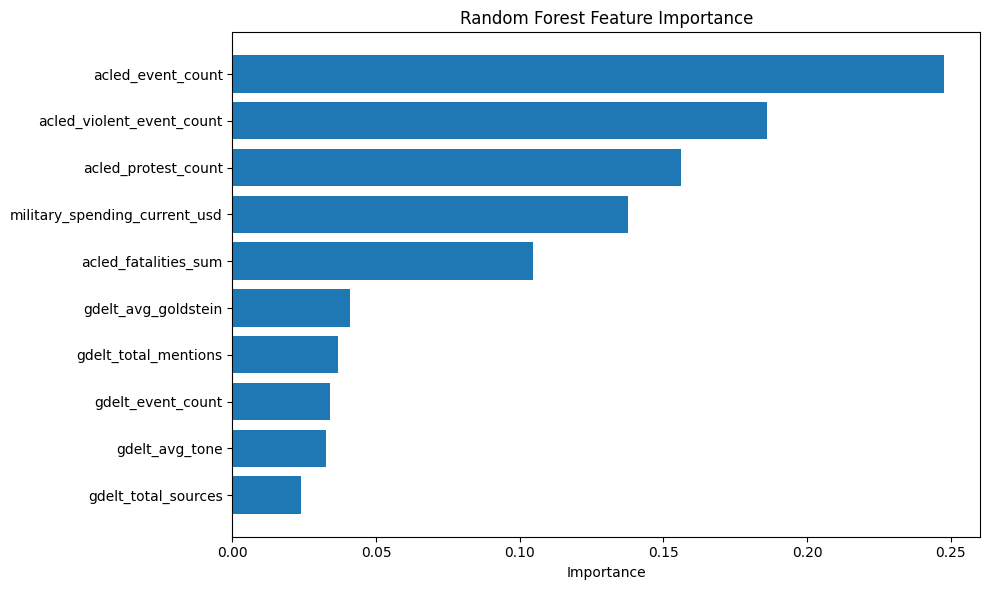

In [36]:
plt.figure(figsize=(10, 6))
plt.barh(rf_importance["feature"].head(10)[::-1], rf_importance["importance"].head(10)[::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### XGBoost Feature Importance

In [37]:
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(xgb_importance.head(10))

                         feature  importance
0              acled_event_count    0.553803
2      acled_violent_event_count    0.142644
5                 gdelt_avg_tone    0.121454
1           acled_fatalities_sum    0.035492
9  military_spending_current_usd    0.035476
6            gdelt_avg_goldstein    0.026144
3            acled_protest_count    0.024661
8            gdelt_total_sources    0.023684
7           gdelt_total_mentions    0.021157
4              gdelt_event_count    0.015485


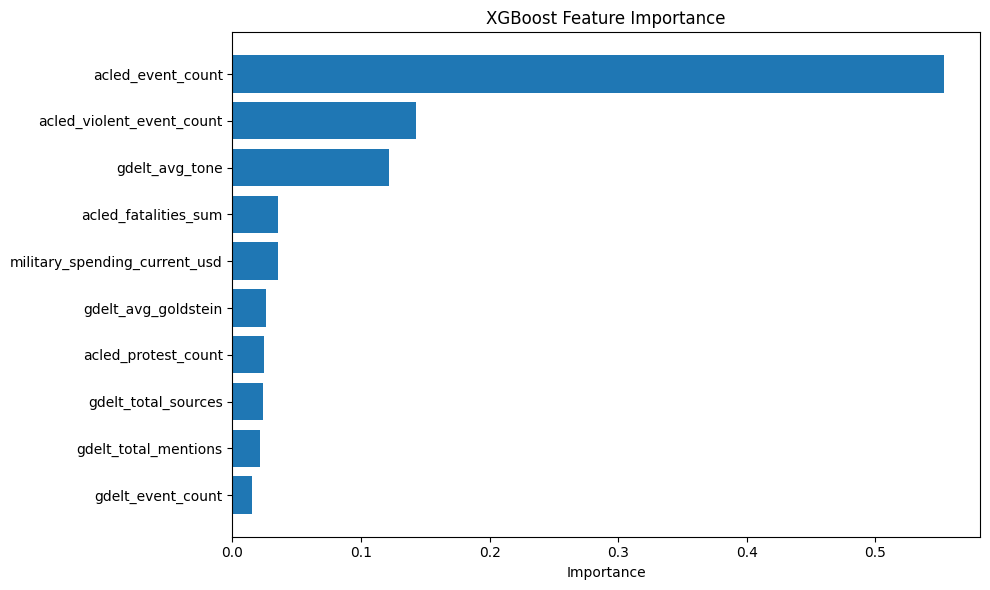

In [38]:
plt.figure(figsize=(10, 6))
plt.barh(xgb_importance["feature"].head(10)[::-1], xgb_importance["importance"].head(10)[::-1])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [3]:
import duckdb
import os

os.makedirs('../clean/data', exist_ok=True)
con = duckdb.connect("../data/conflict_prediction.duckdb", read_only = True)

tables = [
    'dim_country',
    'fact_acled_event',
    'fact_gdelt_event',
    'fact_country_year'
]

for table in tables:
    try:
        df = con.execute(f"SELECT * FROM {table}").fetchdf()
        path = f"../data/clean/{table}.csv"
        df.to_csv(path, index=False)
        size = os.path.getsize(path) / 1e6
        print(f"{table}: {len(df):,} rows -> {path} ({size:.1f} MB)")
    except Exception as e:
        print(f"{table}: FAILED — {e}")

con.close()
print("\nDone! CSVs saved to data")


dim_country: 15 rows -> ../data/clean/dim_country.csv (0.0 MB)
fact_acled_event: 144,526 rows -> ../data/clean/fact_acled_event.csv (13.9 MB)
fact_gdelt_event: 2,148,627 rows -> ../data/clean/fact_gdelt_event.csv (351.7 MB)
fact_country_year: 847 rows -> ../data/clean/fact_country_year.csv (0.1 MB)

Done! CSVs saved to data
